In [1]:
# All imports needed across the whole notebook
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchaudio
import torchaudio.transforms as T
import torchvision
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from sklearn.metrics import classification_report
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
import wave as wave_module
import soundfile as sf
import numpy as np

def load_wav_info(file_path):
    with wave_module.open(str(file_path), 'rb') as wf:
        sr = wf.getframerate()
        ch = wf.getnchannels()
        b  = wf.readframes(wf.getnframes())
        w  = torch.from_numpy(np.frombuffer(b, dtype=np.int16).copy()).float()
        w  = w.view(-1, ch).T / 32768.0
    return w, sr

In [3]:
# Use GPU if available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.memory_allocated(0)/1e9:.2f} GB allocated')
else:
    print('WARNING: No GPU found — this will be very slow with 5 models')

GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Memory: 0.00 GB allocated


In [5]:
# Count audio files per class to understand dataset size
dataset_path = Path('../gunshot-audio-dataset')
class_names = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])

print('Dataset classes:')
for class_name in class_names:
    class_path = dataset_path / class_name
    file_count = len(list(class_path.glob('*.wav')))
    print(f'  {class_name}: {file_count} files')

Dataset classes:
  AK-12: 98 files
  AK-47: 72 files
  IMI Desert Eagle: 100 files
  M16: 100 files
  M249: 99 files
  M4: 100 files
  MG-42: 100 files
  MP5: 100 files
  Zastava M92: 82 files


In [6]:
# Check whether files are mono or stereo
mono_count = 0
stereo_count = 0

for class_name in class_names:
    class_path = dataset_path / class_name
    for audio_file in class_path.glob('*.wav'):
        waveform, sr = load_wav_info(audio_file)
        if waveform.shape[0] == 1:
            mono_count += 1
        else:
            stereo_count += 1

print(f'Mono files: {mono_count}')
print(f'Stereo files: {stereo_count}')

Mono files: 0
Stereo files: 851


In [7]:
# Count how many files exist at each sample rate
sample_rate_counts = {}

for class_name in class_names:
    class_path = dataset_path / class_name
    for audio_file in class_path.glob('*.wav'):
        waveform, sr = load_wav_info(audio_file)
        sample_rate_counts[sr] = sample_rate_counts.get(sr, 0) + 1

for sr, count in sorted(sample_rate_counts.items()):
    print(f'{sr} Hz: {count} files')

44100 Hz: 197 files
48000 Hz: 654 files


In [8]:
# Check how long the audio files are across the dataset
durations = []
duration_counts = {}

for class_name in class_names:
    class_path = dataset_path / class_name
    for audio_file in class_path.glob('*.wav'):
        waveform, sr = load_wav_info(audio_file)
        duration = waveform.shape[1] / sr
        durations.append(duration)
        key = round(duration, 2)
        duration_counts[key] = duration_counts.get(key, 0) + 1

print(f'Shortest duration: {min(durations):.2f}s')
print(f'Longest duration:  {max(durations):.2f}s')
print(f'Average duration:  {sum(durations)/len(durations):.2f}s')
print(f'\nUnique durations: {len(duration_counts)}')
for dur, count in sorted(duration_counts.items()):
    print(f'  {dur:.2f}s: {count} files')

if len(duration_counts) > 5:
    print('\nALERT: Durations vary significantly across files')

Shortest duration: 1.00s
Longest duration:  360.00s
Average duration:  3.04s

Unique durations: 7
  1.00s: 100 files
  2.00s: 745 files
  3.00s: 2 files
  4.00s: 1 files
  305.00s: 1 files
  320.00s: 1 files
  360.00s: 1 files

ALERT: Durations vary significantly across files


In [9]:
# Flag any significant class imbalance
class_file_counts = {}

for class_name in class_names:
    class_path = dataset_path / class_name
    class_file_counts[class_name] = len(list(class_path.glob('*.wav')))

max_count = max(class_file_counts.values())
min_count = min(class_file_counts.values())

print('Class distribution:')
for class_name, count in class_file_counts.items():
    print(f'  {class_name}: {count} files')

if max_count > 2 * min_count:
    print(f'\nClass imbalance detected: max={max_count}, min={min_count}')

Class distribution:
  AK-12: 98 files
  AK-47: 72 files
  IMI Desert Eagle: 100 files
  M16: 100 files
  M249: 99 files
  M4: 100 files
  MG-42: 100 files
  MP5: 100 files
  Zastava M92: 82 files


In [10]:
# Individual preprocessing functions — each does exactly one thing
def convert_to_mono(waveform):
    if waveform.shape[0] > 1:
        return torch.mean(waveform, dim=0, keepdim=True)
    return waveform

def resample_audio(waveform, orig_sr, target_sr=48000):
    if orig_sr != target_sr:
        resampler = T.Resample(orig_sr, target_sr)
        return resampler(waveform)
    return waveform

def pad_or_crop(waveform, target_length):
    current_length = waveform.shape[1]
    if current_length < target_length:
        padding = target_length - current_length
        waveform = torch.nn.functional.pad(waveform, (0, padding))
    elif current_length > target_length:
        waveform = waveform[:, :target_length]
    return waveform

def apply_preemphasis(waveform, coef=0.97):
    return torch.cat([waveform[:, :1], waveform[:, 1:] - coef * waveform[:, :-1]], dim=1)

def normalize_audio(waveform):
    return waveform / (torch.max(torch.abs(waveform)) + 1e-8)

In [11]:
# Chain all preprocessing steps into one pipeline function
def preprocess_audio(file_path, target_sr=48000, target_duration=2.0):
    waveform, sr = load_wav_info(file_path)
    waveform = convert_to_mono(waveform)
    waveform = resample_audio(waveform, sr, target_sr)
    target_length = int(target_sr * target_duration)
    waveform = pad_or_crop(waveform, target_length)
    waveform = apply_preemphasis(waveform)
    waveform = normalize_audio(waveform)
    return waveform, target_sr

In [12]:
# Preprocess all audio and write standardised 48kHz wav files
output_path = Path('processed-audio-48k')
output_path.mkdir(exist_ok=True)

print('Preprocessing audio files...')
for class_name in class_names:
    class_output_path = output_path / class_name
    class_output_path.mkdir(exist_ok=True)

    audio_files = list((dataset_path / class_name).glob('*.wav'))
    for audio_file in audio_files:
        waveform, sr = preprocess_audio(audio_file)
        sf.write(str(class_output_path / audio_file.name), waveform.squeeze(0).numpy(), sr)

    print(f'  Processed {len(audio_files)} files for {class_name}')

print('Preprocessing complete')

Preprocessing audio files...
  Processed 98 files for AK-12
  Processed 72 files for AK-47
  Processed 100 files for IMI Desert Eagle
  Processed 100 files for M16
  Processed 99 files for M249
  Processed 100 files for M4
  Processed 100 files for MG-42
  Processed 100 files for MP5
  Processed 82 files for Zastava M92
Preprocessing complete


In [13]:
# Extract MFCC features from preprocessed audio and save as tensors
features_path = Path('features')
features_path.mkdir(exist_ok=True)

mfcc_transform = T.MFCC(
    sample_rate=48000,
    n_mfcc=40,
    melkwargs={'n_fft': 1024, 'hop_length': 512, 'n_mels': 64}
)

print('Extracting MFCC features...')
for class_name in class_names:
    class_features_path = features_path / class_name
    class_features_path.mkdir(exist_ok=True)

    audio_files = list((output_path / class_name).glob('*.wav'))
    for audio_file in audio_files:
        waveform, sr = load_wav_info(audio_file)
        mfcc = mfcc_transform(waveform)
        torch.save(mfcc, class_features_path / f'{audio_file.stem}.pt')

    print(f'  Extracted features for {len(audio_files)} files in {class_name}')

print('Feature extraction complete')

Extracting MFCC features...
  Extracted features for 98 files in AK-12
  Extracted features for 72 files in AK-47
  Extracted features for 100 files in IMI Desert Eagle
  Extracted features for 100 files in M16
  Extracted features for 99 files in M249
  Extracted features for 100 files in M4
  Extracted features for 100 files in MG-42
  Extracted features for 100 files in MP5
  Extracted features for 82 files in Zastava M92
Feature extraction complete


In [14]:
# Map gun classes to integer labels — M16 and M4 share label 3 as M-Family
class_to_idx = {
    'AK-12': 0,
    'AK-47': 1,
    'IMI Desert Eagle': 2,
    'M16': 3,
    'M4': 3,
    'M249': 4,
    'MG-42': 5,
    'MP5': 6,
    'Zastava M92': 7
}

idx_to_class = {
    0: 'AK-12',
    1: 'AK-47',
    2: 'IMI Desert Eagle',
    3: 'M-Family',
    4: 'M249',
    5: 'MG-42',
    6: 'MP5',
    7: 'Zastava M92'
}

print('class_to_idx:')
for name, idx in class_to_idx.items():
    print(f'  {name} -> {idx}')
print('\nidx_to_class:')
for idx, name in idx_to_class.items():
    print(f'  {idx} -> {name}')

class_to_idx:
  AK-12 -> 0
  AK-47 -> 1
  IMI Desert Eagle -> 2
  M16 -> 3
  M4 -> 3
  M249 -> 4
  MG-42 -> 5
  MP5 -> 6
  Zastava M92 -> 7

idx_to_class:
  0 -> AK-12
  1 -> AK-47
  2 -> IMI Desert Eagle
  3 -> M-Family
  4 -> M249
  5 -> MG-42
  6 -> MP5
  7 -> Zastava M92


In [15]:
# Dataset that loads saved MFCC tensors and optionally augments them
class GunshotDataset(Dataset):
    def __init__(self, features_path, class_to_idx, augment=False):
        self.features_path = Path(features_path)
        self.class_to_idx = class_to_idx
        self.augment = augment
        self.samples = []

        for class_name, label in class_to_idx.items():
            class_path = self.features_path / class_name
            if class_path.exists():
                for feature_file in class_path.glob('*.pt'):
                    self.samples.append((feature_file, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        feature_file, label = self.samples[idx]
        features = torch.load(feature_file, weights_only=True)

        if self.augment:
            if torch.rand(1).item() < 0.5:
                features = features + torch.randn_like(features) * 0.01
            if torch.rand(1).item() < 0.5:
                shift = torch.randint(-10, 11, (1,)).item()
                features = torch.roll(features, shifts=shift, dims=-1)

        return features, label

full_dataset = GunshotDataset('features', class_to_idx, augment=False)
print(f'Total samples: {len(full_dataset)}')

Total samples: 851


In [16]:
# Compute inverse-frequency weights to handle class imbalance in the loss
class_counts = torch.zeros(8)
for _, label in GunshotDataset('features', class_to_idx, augment=False):
    class_counts[label] += 1

class_weights = 1.0 / class_counts.clamp(min=1).clamp(min=1)
class_weights = class_weights / class_weights.sum()
print('Class counts:', class_counts.int().tolist())
class_weights = class_weights.to(device)

print('Class weights:')
for i, w in enumerate(class_weights):
    print(f'  {idx_to_class[i]}: {w.item():.4f}')

Class counts: [98, 72, 100, 200, 99, 100, 100, 82]
Class weights:
  AK-12: 0.1254
  AK-47: 0.1706
  IMI Desert Eagle: 0.1229
  M-Family: 0.0614
  M249: 0.1241
  MG-42: 0.1229
  MP5: 0.1229
  Zastava M92: 0.1498


In [17]:
from sklearn.model_selection import train_test_split
from torch.utils.data import WeightedRandomSampler

torch.manual_seed(42)

all_samples = GunshotDataset('features', class_to_idx, augment=False).samples
all_indices = list(range(len(all_samples)))
all_labels  = [label for _, label in all_samples]

train_indices, temp_indices, train_labels, temp_labels = train_test_split(
    all_indices, all_labels, test_size=0.30, stratify=all_labels, random_state=42
)
val_indices, test_indices = train_test_split(
    temp_indices, test_size=0.50, stratify=temp_labels, random_state=42
)

base_dataset    = GunshotDataset('features', class_to_idx, augment=False)
augment_dataset = GunshotDataset('features', class_to_idx, augment=True)

train_dataset = torch.utils.data.Subset(augment_dataset, train_indices)
val_dataset   = torch.utils.data.Subset(base_dataset, val_indices)
test_dataset  = torch.utils.data.Subset(base_dataset, test_indices)

train_labels_list = [all_labels[i] for i in train_indices]
sample_weights    = [1.0 / class_counts[label].item() for label in train_labels_list]
sampler           = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f'Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}')

Train: 595, Val: 128, Test: 128


In [18]:
# Custom CNN for gunshot classification
class GunshotCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(GunshotCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [19]:
# Instantiate GunshotCNN and move to the active device
cnn_model = GunshotCNN(num_classes=8).to(device)
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'GunshotCNN initialized on {device}')
print(f'Trainable parameters: {total_params:,}')

GunshotCNN initialized on cuda
Trainable parameters: 169,288


In [20]:
# Optimizer, scheduler, and weighted loss for GunshotCNN
cnn_criterion = nn.CrossEntropyLoss(weight=class_weights)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.0005, weight_decay=2e-3)
cnn_scheduler = optim.lr_scheduler.CosineAnnealingLR(cnn_optimizer, T_max=50, eta_min=1e-6)

print('Loss: Weighted CrossEntropyLoss')
print('Optimizer: Adam, lr=0.0005, weight_decay=2e-3')
print('Scheduler: CosineAnnealingLR, T_max=50, eta_min=1e-6')

Loss: Weighted CrossEntropyLoss
Optimizer: Adam, lr=0.0005, weight_decay=2e-3
Scheduler: CosineAnnealingLR, T_max=50, eta_min=1e-6


In [21]:
# Training hyperparameters and history containers for GunshotCNN
num_epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

cnn_train_losses = []
cnn_train_accuracies = []
cnn_val_losses = []
cnn_val_accuracies = []

print(f'Training for up to {num_epochs} epochs with early stopping patience={patience}')

Training for up to 50 epochs with early stopping patience=5


In [22]:
# Train GunshotCNN with early stopping
for epoch in range(num_epochs):
    cnn_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        cnn_optimizer.zero_grad()
        outputs = cnn_model(features)
        loss = cnn_criterion(outputs, labels)
        loss.backward()
        cnn_optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    cnn_train_losses.append(train_loss)
    cnn_train_accuracies.append(train_acc)

    cnn_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = cnn_model(features)
            loss = cnn_criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    cnn_val_losses.append(val_loss)
    cnn_val_accuracies.append(val_acc)

    cnn_scheduler.step()

    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | LR: {cnn_optimizer.param_groups[0]["lr"]:.6f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(cnn_model.state_dict(), 'best_gunshot_cnn.pth')
        print(f'  Saved best model with val_loss: {val_loss:.4f}')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

print('GunshotCNN training complete')

Epoch 1/50 | Train Loss: 1.9360 Acc: 20.34% | Val Loss: 1.8046 Acc: 29.69% | LR: 0.000500
  Saved best model with val_loss: 1.8046
Epoch 2/50 | Train Loss: 1.5121 Acc: 37.14% | Val Loss: 1.5390 Acc: 34.38% | LR: 0.000498
  Saved best model with val_loss: 1.5390
Epoch 3/50 | Train Loss: 1.3285 Acc: 42.35% | Val Loss: 1.3835 Acc: 37.50% | LR: 0.000496
  Saved best model with val_loss: 1.3835
Epoch 4/50 | Train Loss: 1.2602 Acc: 43.87% | Val Loss: 1.2555 Acc: 40.62% | LR: 0.000492
  Saved best model with val_loss: 1.2555
Epoch 5/50 | Train Loss: 1.1507 Acc: 51.09% | Val Loss: 1.2345 Acc: 42.19% | LR: 0.000488
  Saved best model with val_loss: 1.2345
Epoch 6/50 | Train Loss: 1.0771 Acc: 52.27% | Val Loss: 1.1324 Acc: 53.12% | LR: 0.000482
  Saved best model with val_loss: 1.1324
Epoch 7/50 | Train Loss: 1.0313 Acc: 56.97% | Val Loss: 1.0984 Acc: 52.34% | LR: 0.000476
  Saved best model with val_loss: 1.0984
Epoch 8/50 | Train Loss: 0.9789 Acc: 57.48% | Val Loss: 1.0428 Acc: 53.91% | LR: 0.

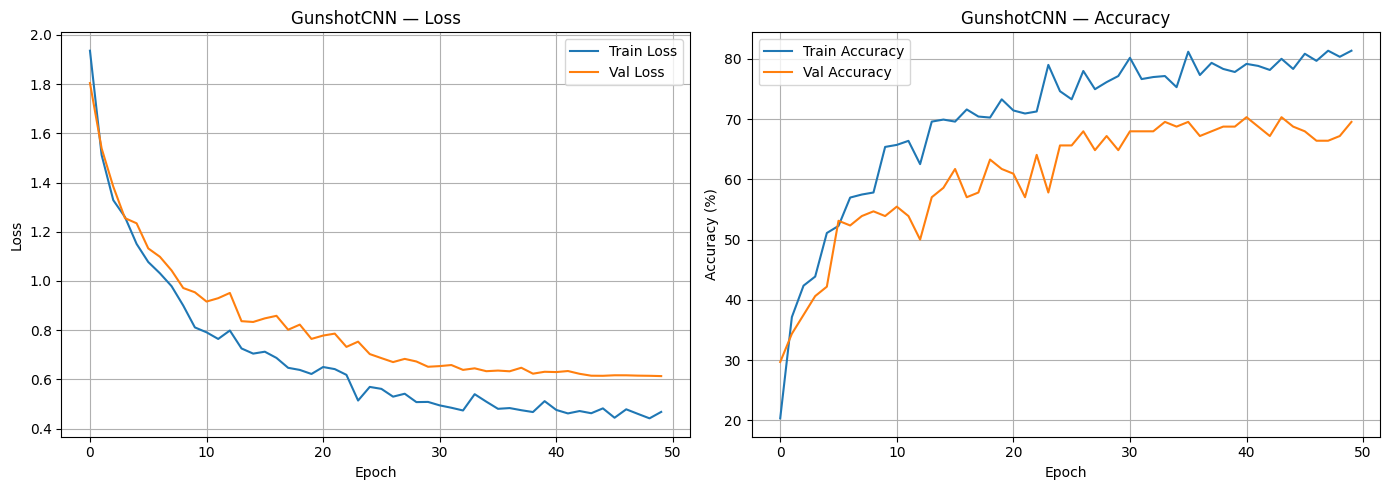

In [23]:
# Training curves for GunshotCNN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cnn_train_losses, label='Train Loss')
ax1.plot(cnn_val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('GunshotCNN — Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(cnn_train_accuracies, label='Train Accuracy')
ax2.plot(cnn_val_accuracies, label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('GunshotCNN — Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [24]:
# Load best weights and evaluate GunshotCNN on the validation set
cnn_model.load_state_dict(torch.load('best_gunshot_cnn.pth', weights_only=True))
cnn_model.eval()

val_preds, val_labels = [], []
with torch.no_grad():
    for features, labels in val_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = cnn_model(features)
        _, predicted = torch.max(outputs, 1)
        val_preds.extend(predicted.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())

print('GunshotCNN — Validation Set Classification Report:\n')
print(classification_report(val_labels, val_preds, target_names=[idx_to_class[i] for i in range(8)]))

GunshotCNN — Validation Set Classification Report:

                  precision    recall  f1-score   support

           AK-12       1.00      1.00      1.00        14
           AK-47       0.92      1.00      0.96        11
IMI Desert Eagle       0.57      0.87      0.68        15
        M-Family       1.00      0.20      0.33        30
            M249       0.45      0.60      0.51        15
           MG-42       0.76      0.87      0.81        15
             MP5       0.43      0.67      0.53        15
     Zastava M92       1.00      1.00      1.00        13

        accuracy                           0.70       128
       macro avg       0.77      0.77      0.73       128
    weighted avg       0.78      0.70      0.67       128



In [25]:
# Evaluate GunshotCNN on the held-out test set
cnn_model.eval()
test_correct = 0
test_total = 0
test_preds, test_labels_list = [], []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = cnn_model(features)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        test_preds.extend(predicted.cpu().numpy())
        test_labels_list.extend(labels.cpu().numpy())

cnn_test_accuracy = 100 * test_correct / test_total
print(f'GunshotCNN Test Accuracy: {cnn_test_accuracy:.2f}%\n')
print(classification_report(test_labels_list, test_preds, target_names=[idx_to_class[i] for i in range(8)]))

GunshotCNN Test Accuracy: 71.88%

                  precision    recall  f1-score   support

           AK-12       1.00      1.00      1.00        15
           AK-47       0.91      0.91      0.91        11
IMI Desert Eagle       0.60      0.80      0.69        15
        M-Family       0.86      0.40      0.55        30
            M249       0.53      0.60      0.56        15
           MG-42       0.57      0.87      0.68        15
             MP5       0.56      0.60      0.58        15
     Zastava M92       1.00      1.00      1.00        12

        accuracy                           0.72       128
       macro avg       0.75      0.77      0.75       128
    weighted avg       0.75      0.72      0.71       128



In [26]:
# EfficientNet-B0 adapted for single-channel MFCC input
class EfficientNetAudio(nn.Module):
    def __init__(self, num_classes=8):
        super(EfficientNetAudio, self).__init__()
        self.model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

        # Freeze all parameters first
        for param in self.model.parameters():
            param.requires_grad = False

        # Replace first conv to accept 1-channel input
        self.model.features[0][0] = nn.Conv2d(
            1, 32, kernel_size=3, stride=2, padding=1, bias=False
        )

        # Replace classifier head
        self.model.classifier = nn.Linear(1280, num_classes)

        # Unfreeze the modified layers
        for param in self.model.features[0][0].parameters():
            param.requires_grad = True
        for param in self.model.classifier.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)

In [27]:
# Instantiate EfficientNetAudio and report trainable parameter count
eff_model = EfficientNetAudio(num_classes=8).to(device)
trainable = sum(p.numel() for p in eff_model.parameters() if p.requires_grad)
print(f'EfficientNetAudio initialized on {device}')
print(f'Trainable parameters: {trainable:,}')

EfficientNetAudio initialized on cuda
Trainable parameters: 10,536


In [28]:
# Optimizer, scheduler, and criterion for EfficientNet
eff_criterion = nn.CrossEntropyLoss(weight=class_weights)
eff_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, eff_model.parameters()),
    lr=0.0005, weight_decay=2e-3
)
eff_scheduler = optim.lr_scheduler.CosineAnnealingLR(eff_optimizer, T_max=50, eta_min=1e-6)

print('EfficientNet optimizer initialized')

EfficientNet optimizer initialized


In [29]:
# Training configuration for EfficientNet — fresh history and counters
num_epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

eff_train_losses = []
eff_train_accuracies = []
eff_val_losses = []
eff_val_accuracies = []

print(f'Training EfficientNet for up to {num_epochs} epochs with patience={patience}')

Training EfficientNet for up to 50 epochs with patience=5


In [30]:
# Train EfficientNetAudio with early stopping
for epoch in range(num_epochs):
    eff_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        eff_optimizer.zero_grad()
        outputs = eff_model(features)
        loss = eff_criterion(outputs, labels)
        loss.backward()
        eff_optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    eff_train_losses.append(train_loss)
    eff_train_accuracies.append(train_acc)

    eff_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = eff_model(features)
            loss = eff_criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    eff_val_losses.append(val_loss)
    eff_val_accuracies.append(val_acc)

    eff_scheduler.step()

    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | LR: {eff_optimizer.param_groups[0]["lr"]:.6f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(eff_model.state_dict(), 'best_gunshot_efficientnet.pth')
        print(f'  Saved best model with val_loss: {val_loss:.4f}')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

print('EfficientNet training complete')

Epoch 1/50 | Train Loss: 2.0003 Acc: 20.84% | Val Loss: 1.9065 Acc: 28.12% | LR: 0.000500
  Saved best model with val_loss: 1.9065
Epoch 2/50 | Train Loss: 1.6866 Acc: 47.23% | Val Loss: 1.6107 Acc: 46.88% | LR: 0.000498
  Saved best model with val_loss: 1.6107
Epoch 3/50 | Train Loss: 1.4714 Acc: 54.12% | Val Loss: 1.4491 Acc: 46.88% | LR: 0.000496
  Saved best model with val_loss: 1.4491
Epoch 4/50 | Train Loss: 1.3620 Acc: 54.45% | Val Loss: 1.3402 Acc: 47.66% | LR: 0.000492
  Saved best model with val_loss: 1.3402
Epoch 5/50 | Train Loss: 1.2779 Acc: 56.64% | Val Loss: 1.2534 Acc: 53.12% | LR: 0.000488
  Saved best model with val_loss: 1.2534
Epoch 6/50 | Train Loss: 1.1487 Acc: 62.35% | Val Loss: 1.1745 Acc: 52.34% | LR: 0.000482
  Saved best model with val_loss: 1.1745
Epoch 7/50 | Train Loss: 1.1512 Acc: 60.67% | Val Loss: 1.1135 Acc: 57.81% | LR: 0.000476
  Saved best model with val_loss: 1.1135
Epoch 8/50 | Train Loss: 1.0675 Acc: 60.67% | Val Loss: 1.1012 Acc: 57.03% | LR: 0.

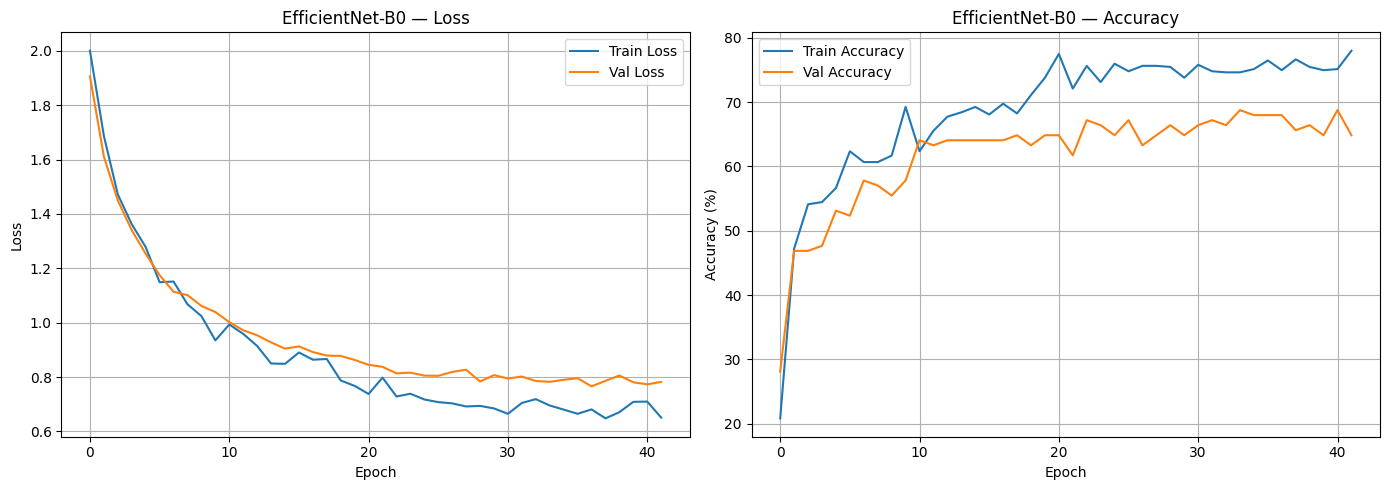

In [31]:
# Training curves for EfficientNet
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(eff_train_losses, label='Train Loss')
ax1.plot(eff_val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('EfficientNet-B0 — Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(eff_train_accuracies, label='Train Accuracy')
ax2.plot(eff_val_accuracies, label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('EfficientNet-B0 — Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [32]:
# Load best EfficientNet weights and evaluate on validation set
eff_model.load_state_dict(torch.load('best_gunshot_efficientnet.pth', weights_only=True))
eff_model.eval()

eff_val_preds, eff_val_labels = [], []
with torch.no_grad():
    for features, labels in val_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = eff_model(features)
        _, predicted = torch.max(outputs, 1)
        eff_val_preds.extend(predicted.cpu().numpy())
        eff_val_labels.extend(labels.cpu().numpy())

print('EfficientNet-B0 — Validation Set Classification Report:\n')
print(classification_report(eff_val_labels, eff_val_preds, target_names=[idx_to_class[i] for i in range(8)]))

EfficientNet-B0 — Validation Set Classification Report:

                  precision    recall  f1-score   support

           AK-12       0.92      0.86      0.89        14
           AK-47       0.85      1.00      0.92        11
IMI Desert Eagle       0.41      0.73      0.52        15
        M-Family       0.85      0.37      0.51        30
            M249       0.46      0.40      0.43        15
           MG-42       0.81      0.87      0.84        15
             MP5       0.50      0.67      0.57        15
     Zastava M92       1.00      1.00      1.00        13

        accuracy                           0.68       128
       macro avg       0.72      0.74      0.71       128
    weighted avg       0.73      0.68      0.67       128



In [33]:
# Evaluate EfficientNet on the test set
eff_model.eval()
test_correct = 0
test_total = 0
eff_test_preds, eff_test_labels = [], []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = eff_model(features)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        eff_test_preds.extend(predicted.cpu().numpy())
        eff_test_labels.extend(labels.cpu().numpy())

eff_test_accuracy = 100 * test_correct / test_total
print(f'EfficientNet-B0 Test Accuracy: {eff_test_accuracy:.2f}%\n')
print(classification_report(eff_test_labels, eff_test_preds, target_names=[idx_to_class[i] for i in range(8)]))

EfficientNet-B0 Test Accuracy: 67.19%

                  precision    recall  f1-score   support

           AK-12       0.93      0.87      0.90        15
           AK-47       0.59      0.91      0.71        11
IMI Desert Eagle       0.59      0.67      0.62        15
        M-Family       0.78      0.47      0.58        30
            M249       0.53      0.67      0.59        15
           MG-42       0.64      0.93      0.76        15
             MP5       0.40      0.27      0.32        15
     Zastava M92       1.00      0.92      0.96        12

        accuracy                           0.67       128
       macro avg       0.68      0.71      0.68       128
    weighted avg       0.69      0.67      0.66       128



In [34]:
# MobileNetV2 adapted for single-channel MFCC input
class MobileNetAudio(nn.Module):
    def __init__(self, num_classes=8):
        super(MobileNetAudio, self).__init__()
        self.model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

        # Freeze all parameters first
        for param in self.model.parameters():
            param.requires_grad = False

        # Replace first conv to accept 1-channel input
        self.model.features[0][0] = nn.Conv2d(
            1, 32, kernel_size=3, stride=2, padding=1, bias=False
        )

        # Replace classifier head
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(1280, num_classes)
        )

        # Unfreeze modified layers
        for param in self.model.features[0][0].parameters():
            param.requires_grad = True
        for param in self.model.classifier.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)

In [35]:
# Instantiate MobileNetAudio and report trainable parameter count
mob_model = MobileNetAudio(num_classes=8).to(device)
trainable = sum(p.numel() for p in mob_model.parameters() if p.requires_grad)
print(f'MobileNetAudio initialized on {device}')
print(f'Trainable parameters: {trainable:,}')

MobileNetAudio initialized on cuda
Trainable parameters: 10,536


In [36]:
# Optimizer, scheduler, and criterion for MobileNet
mob_criterion = nn.CrossEntropyLoss(weight=class_weights)
mob_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, mob_model.parameters()),
    lr=0.0005, weight_decay=2e-3
)
mob_scheduler = optim.lr_scheduler.CosineAnnealingLR(mob_optimizer, T_max=50, eta_min=1e-6)

print('MobileNet optimizer initialized')

MobileNet optimizer initialized


In [37]:
# Training configuration for MobileNet — fresh history and counters
num_epochs = 50
patience = 5
best_val_loss = float('inf')
patience_counter = 0

mob_train_losses = []
mob_train_accuracies = []
mob_val_losses = []
mob_val_accuracies = []

print(f'Training MobileNet for up to {num_epochs} epochs with patience={patience}')

Training MobileNet for up to 50 epochs with patience=5


In [38]:
# Train MobileNetAudio with early stopping
for epoch in range(num_epochs):
    mob_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        mob_optimizer.zero_grad()
        outputs = mob_model(features)
        loss = mob_criterion(outputs, labels)
        loss.backward()
        mob_optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    mob_train_losses.append(train_loss)
    mob_train_accuracies.append(train_acc)

    mob_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = mob_model(features)
            loss = mob_criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    mob_val_losses.append(val_loss)
    mob_val_accuracies.append(val_acc)

    mob_scheduler.step()

    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | LR: {mob_optimizer.param_groups[0]["lr"]:.6f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(mob_model.state_dict(), 'best_gunshot_mobilenet.pth')
        print(f'  Saved best model with val_loss: {val_loss:.4f}')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

print('MobileNet training complete')

Epoch 1/50 | Train Loss: 1.9916 Acc: 21.34% | Val Loss: 1.9439 Acc: 33.59% | LR: 0.000500
  Saved best model with val_loss: 1.9439
Epoch 2/50 | Train Loss: 1.7240 Acc: 45.21% | Val Loss: 1.7302 Acc: 40.62% | LR: 0.000498
  Saved best model with val_loss: 1.7302
Epoch 3/50 | Train Loss: 1.5501 Acc: 50.59% | Val Loss: 1.5952 Acc: 50.00% | LR: 0.000496
  Saved best model with val_loss: 1.5952
Epoch 4/50 | Train Loss: 1.4260 Acc: 54.79% | Val Loss: 1.5013 Acc: 45.31% | LR: 0.000492
  Saved best model with val_loss: 1.5013
Epoch 5/50 | Train Loss: 1.3022 Acc: 58.49% | Val Loss: 1.3972 Acc: 47.66% | LR: 0.000488
  Saved best model with val_loss: 1.3972
Epoch 6/50 | Train Loss: 1.2301 Acc: 59.16% | Val Loss: 1.3331 Acc: 53.12% | LR: 0.000482
  Saved best model with val_loss: 1.3331
Epoch 7/50 | Train Loss: 1.1145 Acc: 63.19% | Val Loss: 1.2947 Acc: 49.22% | LR: 0.000476
  Saved best model with val_loss: 1.2947
Epoch 8/50 | Train Loss: 1.1698 Acc: 59.66% | Val Loss: 1.2928 Acc: 50.78% | LR: 0.

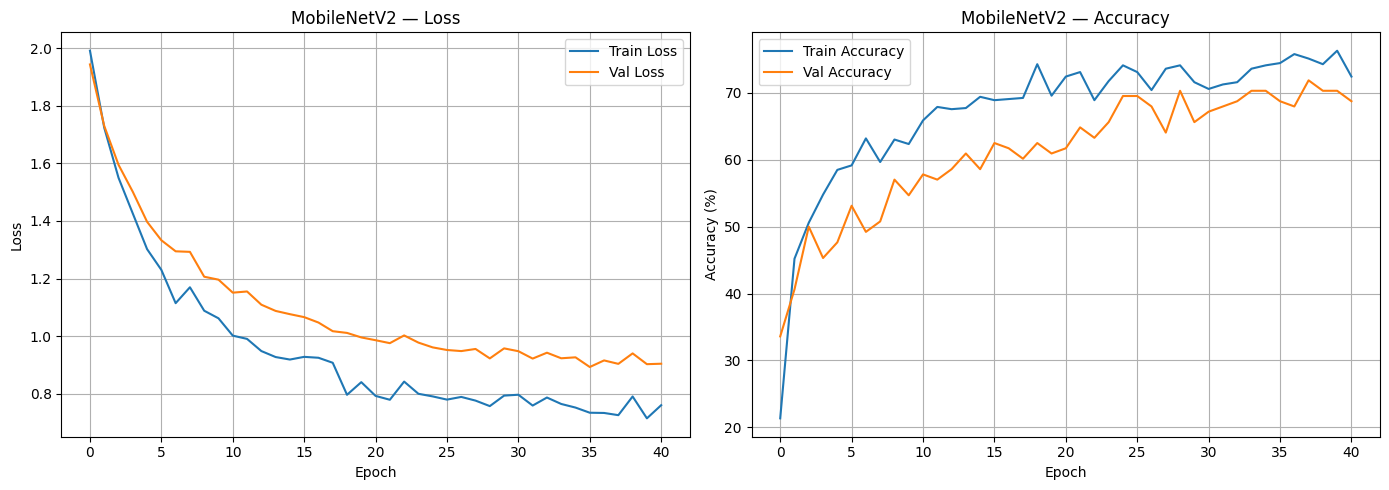

In [39]:
# Training curves for MobileNetV2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(mob_train_losses, label='Train Loss')
ax1.plot(mob_val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MobileNetV2 — Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(mob_train_accuracies, label='Train Accuracy')
ax2.plot(mob_val_accuracies, label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MobileNetV2 — Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [40]:
# Load best MobileNet weights and evaluate on validation set
mob_model.load_state_dict(torch.load('best_gunshot_mobilenet.pth', weights_only=True))
mob_model.eval()

mob_val_preds, mob_val_labels = [], []
with torch.no_grad():
    for features, labels in val_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = mob_model(features)
        _, predicted = torch.max(outputs, 1)
        mob_val_preds.extend(predicted.cpu().numpy())
        mob_val_labels.extend(labels.cpu().numpy())

print('MobileNetV2 — Validation Set Classification Report:\n')
print(classification_report(mob_val_labels, mob_val_preds, target_names=[idx_to_class[i] for i in range(8)]))

MobileNetV2 — Validation Set Classification Report:

                  precision    recall  f1-score   support

           AK-12       0.93      0.93      0.93        14
           AK-47       1.00      0.73      0.84        11
IMI Desert Eagle       0.52      0.73      0.61        15
        M-Family       0.85      0.37      0.51        30
            M249       0.54      0.93      0.68        15
           MG-42       0.71      0.67      0.69        15
             MP5       0.47      0.60      0.53        15
     Zastava M92       0.92      0.92      0.92        13

        accuracy                           0.69       128
       macro avg       0.74      0.73      0.71       128
    weighted avg       0.74      0.69      0.68       128



In [41]:
# Evaluate MobileNet on the test set
mob_model.eval()
test_correct = 0
test_total = 0
mob_test_preds, mob_test_labels = [], []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = mob_model(features)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        mob_test_preds.extend(predicted.cpu().numpy())
        mob_test_labels.extend(labels.cpu().numpy())

mob_test_accuracy = 100 * test_correct / test_total
print(f'MobileNetV2 Test Accuracy: {mob_test_accuracy:.2f}%\n')
print(classification_report(mob_test_labels, mob_test_preds, target_names=[idx_to_class[i] for i in range(8)]))

MobileNetV2 Test Accuracy: 63.28%

                  precision    recall  f1-score   support

           AK-12       0.93      0.93      0.93        15
           AK-47       0.58      0.64      0.61        11
IMI Desert Eagle       0.45      0.60      0.51        15
        M-Family       0.69      0.37      0.48        30
            M249       0.56      0.60      0.58        15
           MG-42       0.67      0.80      0.73        15
             MP5       0.45      0.67      0.54        15
     Zastava M92       1.00      0.75      0.86        12

        accuracy                           0.63       128
       macro avg       0.67      0.67      0.66       128
    weighted avg       0.66      0.63      0.63       128



In [42]:
# Side-by-side accuracy comparison of all three models
header = f"{'Model':<22} {'Train Acc':>10} {'Val Acc':>10} {'Test Acc':>10}"
print(header)
print('-' * len(header))
print(f"{'GunshotCNN':<22} {cnn_train_accuracies[-1]:>9.2f}% {cnn_val_accuracies[-1]:>9.2f}% {cnn_test_accuracy:>9.2f}%")
print(f"{'EfficientNet-B0':<22} {eff_train_accuracies[-1]:>9.2f}% {eff_val_accuracies[-1]:>9.2f}% {eff_test_accuracy:>9.2f}%")
print(f"{'MobileNetV2':<22} {mob_train_accuracies[-1]:>9.2f}% {mob_val_accuracies[-1]:>9.2f}% {mob_test_accuracy:>9.2f}%")

Model                   Train Acc    Val Acc   Test Acc
-------------------------------------------------------
GunshotCNN                 81.34%     69.53%     71.88%
EfficientNet-B0            77.98%     64.84%     67.19%
MobileNetV2                72.44%     68.75%     63.28%


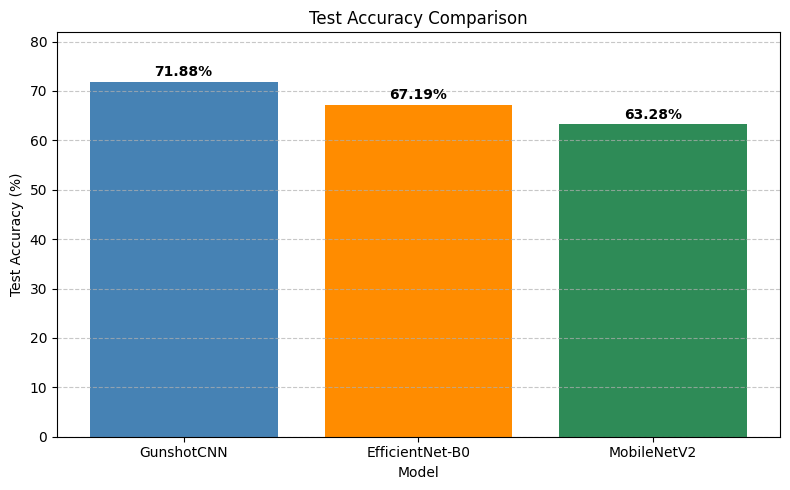

In [43]:
# Bar chart comparing test accuracy across all three models
model_names = ['GunshotCNN', 'EfficientNet-B0', 'MobileNetV2']
test_accuracies = [cnn_test_accuracy, eff_test_accuracy, mob_test_accuracy]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, test_accuracies, color=['steelblue', 'darkorange', 'seagreen'])

for bar, acc in zip(bars, test_accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Model')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy Comparison')
ax.set_ylim(0, max(test_accuracies) + 10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [44]:
# Self-contained inference wrapper — stores everything needed to predict from a wav file
class AudioPipeline:
    def __init__(self, model, class_to_idx, idx_to_class):
        self.target_sr = 48000
        self.target_duration = 2.0
        self.n_mfcc = 40
        self.mfcc_params = {'n_fft': 1024, 'hop_length': 512, 'n_mels': 64}
        self.class_to_idx = class_to_idx
        self.idx_to_class = idx_to_class
        self.model = model.cpu()
        self.model.eval()

    def _convert_to_mono(self, waveform):
        if waveform.shape[0] > 1:
            return torch.mean(waveform, dim=0, keepdim=True)
        return waveform

    def _resample_audio(self, waveform, orig_sr):
        if orig_sr != self.target_sr:
            resampler = T.Resample(orig_sr, self.target_sr)
            return resampler(waveform)
        return waveform

    def _pad_or_crop(self, waveform, target_length):
        current_length = waveform.shape[1]
        if current_length < target_length:
            waveform = torch.nn.functional.pad(waveform, (0, target_length - current_length))
        elif current_length > target_length:
            waveform = waveform[:, :target_length]
        return waveform

    def _apply_preemphasis(self, waveform, coef=0.97):
        return torch.cat([waveform[:, :1], waveform[:, 1:] - coef * waveform[:, :-1]], dim=1)

    def _normalize_audio(self, waveform):
        return waveform / (torch.max(torch.abs(waveform)) + 1e-8)

    def _extract_mfcc(self, waveform):
        mfcc_transform = T.MFCC(
            sample_rate=self.target_sr,
            n_mfcc=self.n_mfcc,
            melkwargs=self.mfcc_params
        )
        return mfcc_transform(waveform)

    def predict(self, file_path):
        waveform, sr = load_wav_info(file_path)
        waveform = self._convert_to_mono(waveform)
        waveform = self._resample_audio(waveform, sr)
        target_length = int(self.target_sr * self.target_duration)
        waveform = self._pad_or_crop(waveform, target_length)
        waveform = self._apply_preemphasis(waveform)
        waveform = self._normalize_audio(waveform)
        mfcc = self._extract_mfcc(waveform)
        mfcc = mfcc.unsqueeze(0)  # add batch dim, stays on cpu

        with torch.no_grad():
            output = self.model(mfcc)
            probabilities = torch.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        predicted_class = self.idx_to_class[predicted.item()]
        confidence_score = confidence.item() * 100
        return predicted_class, confidence_score

In [45]:
# Load best weights into each model, move to cpu, wrap in AudioPipeline, and save with joblib
cnn_model.load_state_dict(torch.load('best_gunshot_cnn.pth', weights_only=True))
eff_model.load_state_dict(torch.load('best_gunshot_efficientnet.pth', weights_only=True))
mob_model.load_state_dict(torch.load('best_gunshot_mobilenet.pth', weights_only=True))

cnn_pipeline = AudioPipeline(cnn_model, class_to_idx, idx_to_class)
eff_pipeline = AudioPipeline(eff_model, class_to_idx, idx_to_class)
mob_pipeline = AudioPipeline(mob_model, class_to_idx, idx_to_class)

joblib.dump(cnn_pipeline, 'gunshot_cnn_pipeline.joblib')
print('Saved gunshot_cnn_pipeline.joblib')

joblib.dump(eff_pipeline, 'gunshot_efficientnet_pipeline.joblib')
print('Saved gunshot_efficientnet_pipeline.joblib')

joblib.dump(mob_pipeline, 'gunshot_mobilenet_pipeline.joblib')
print('Saved gunshot_mobilenet_pipeline.joblib')

Saved gunshot_cnn_pipeline.joblib
Saved gunshot_efficientnet_pipeline.joblib
Saved gunshot_mobilenet_pipeline.joblib


In [46]:
# Load each pipeline from disk and run a test prediction to confirm they work
loaded_cnn = joblib.load('gunshot_cnn_pipeline.joblib')
loaded_eff = joblib.load('gunshot_efficientnet_pipeline.joblib')
loaded_mob = joblib.load('gunshot_mobilenet_pipeline.joblib')

sample_file = list(Path('../gunshot-audio-dataset').rglob('*.wav'))[0]
print(f'Test file: {sample_file.name}\n')

for name, pipeline in [('GunshotCNN', loaded_cnn), ('EfficientNet-B0', loaded_eff), ('MobileNetV2', loaded_mob)]:
    pred_class, confidence = pipeline.predict(sample_file)
    print(f'{name:<22} Predicted: {pred_class:<20} Confidence: {confidence:.2f}%')

Test file: 3 (1).wav

GunshotCNN             Predicted: AK-12                Confidence: 96.21%
EfficientNet-B0        Predicted: AK-12                Confidence: 95.48%
MobileNetV2            Predicted: AK-12                Confidence: 79.67%


In [47]:
# Three conv blocks with batch norm — deeper version of GunshotCNN
class DeepGunshotCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(DeepGunshotCNN, self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.dropout1 = nn.Dropout(0.4)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout2 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.pool(x)
        x = self.dropout1(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [48]:
# Instantiate DeepGunshotCNN and count trainable parameters
deep_model = DeepGunshotCNN(num_classes=8).to(device)
total_params = sum(p.numel() for p in deep_model.parameters())
trainable = sum(p.numel() for p in deep_model.parameters() if p.requires_grad)
print(f'DeepGunshotCNN — Total: {total_params:,}  Trainable: {trainable:,}')


DeepGunshotCNN — Total: 634,632  Trainable: 634,632


In [49]:
# Adam optimizer, cosine scheduler, weighted loss for DeepGunshotCNN
deep_criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
deep_optimizer = torch.optim.Adam(deep_model.parameters(), lr=0.0005, weight_decay=2e-3)
deep_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(deep_optimizer, T_max=50, eta_min=1e-6)


In [50]:
# Training config and empty history lists for DeepGunshotCNN
num_epochs = 50
patience = 5
patience_counter = 0
best_val_loss = float('inf')
deep_train_losses, deep_train_accuracies = [], []
deep_val_losses, deep_val_accuracies = [], []


In [51]:
# Training loop with early stopping — saves best weights to best_gunshot_deep_cnn.pth
for epoch in range(num_epochs):
    deep_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        deep_optimizer.zero_grad()
        outputs = deep_model(features)
        loss = deep_criterion(outputs, labels)
        loss.backward()
        deep_optimizer.step()
        running_loss += loss.item() * features.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = 100 * correct / total
    deep_train_losses.append(train_loss)
    deep_train_accuracies.append(train_acc)

    deep_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = deep_model(features)
            loss = deep_criterion(outputs, labels)
            val_running_loss += loss.item() * features.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = 100 * val_correct / val_total
    deep_val_losses.append(val_loss)
    deep_val_accuracies.append(val_acc)

    deep_scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(deep_model.state_dict(), 'best_gunshot_deep_cnn.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch + 1}')
            break

    if True:
        print(f'Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%')


Epoch   1 | Train Loss: 1.7454  Train Acc: 28.57%  Val Loss: 1.6613  Val Acc: 26.56%
Epoch   2 | Train Loss: 1.3357  Train Acc: 39.16%  Val Loss: 1.3661  Val Acc: 39.84%
Epoch   3 | Train Loss: 1.2210  Train Acc: 45.71%  Val Loss: 1.1428  Val Acc: 46.88%
Epoch   4 | Train Loss: 1.0177  Train Acc: 50.76%  Val Loss: 1.1098  Val Acc: 42.97%
Epoch   5 | Train Loss: 0.9703  Train Acc: 54.45%  Val Loss: 0.9946  Val Acc: 50.00%
Epoch   6 | Train Loss: 0.9020  Train Acc: 57.14%  Val Loss: 0.9885  Val Acc: 52.34%
Epoch   7 | Train Loss: 0.8236  Train Acc: 62.02%  Val Loss: 0.9555  Val Acc: 50.00%
Epoch   8 | Train Loss: 0.7853  Train Acc: 62.18%  Val Loss: 0.9355  Val Acc: 52.34%
Epoch   9 | Train Loss: 0.7745  Train Acc: 62.86%  Val Loss: 0.8320  Val Acc: 57.03%
Epoch  10 | Train Loss: 0.7193  Train Acc: 64.37%  Val Loss: 1.1125  Val Acc: 45.31%
Epoch  11 | Train Loss: 0.6791  Train Acc: 65.38%  Val Loss: 0.7414  Val Acc: 55.47%
Epoch  12 | Train Loss: 0.5675  Train Acc: 75.13%  Val Loss: 0.80

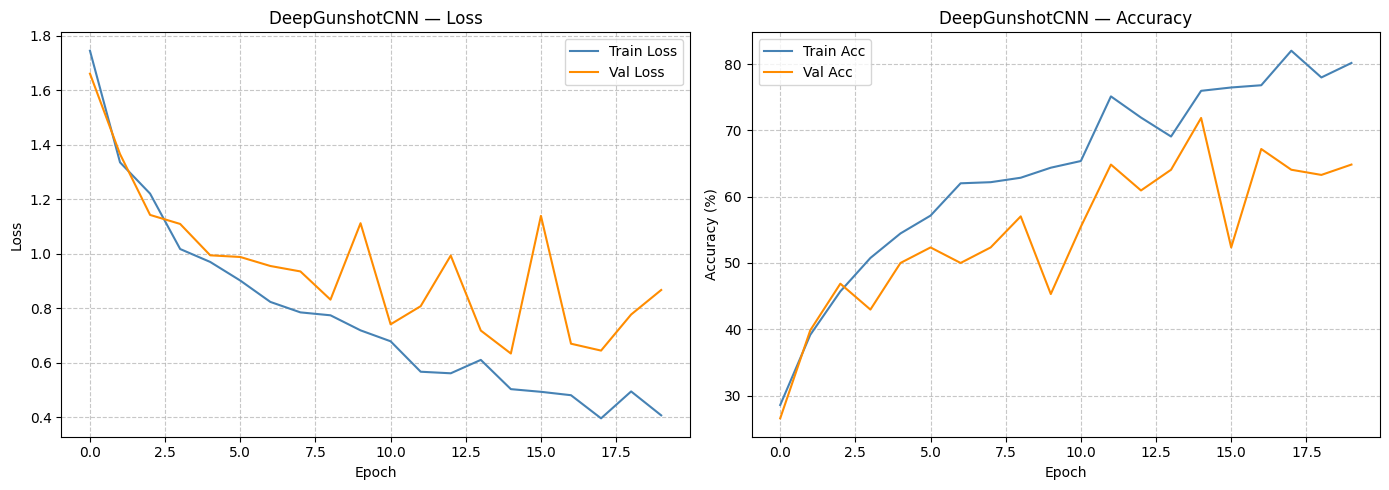

In [52]:
# Training curves for DeepGunshotCNN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(deep_train_losses, label='Train Loss', color='steelblue')
ax1.plot(deep_val_losses, label='Val Loss', color='darkorange')
ax1.set_title('DeepGunshotCNN — Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(linestyle='--', alpha=0.7)

ax2.plot(deep_train_accuracies, label='Train Acc', color='steelblue')
ax2.plot(deep_val_accuracies, label='Val Acc', color='darkorange')
ax2.set_title('DeepGunshotCNN — Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [53]:
# Load best weights and evaluate on validation set
deep_model.load_state_dict(torch.load('best_gunshot_deep_cnn.pth', weights_only=True))
deep_model.eval()

val_preds, val_labels = [], []
with torch.no_grad():
    for features, labels in val_loader:
        features = features.to(device)
        outputs = deep_model(features)
        _, predicted = torch.max(outputs, 1)
        val_preds.extend(predicted.cpu().numpy())
        val_labels.extend(labels.numpy())

target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print('DeepGunshotCNN — Validation Classification Report')
print(classification_report(val_labels, val_preds, target_names=target_names))


DeepGunshotCNN — Validation Classification Report
                  precision    recall  f1-score   support

           AK-12       1.00      1.00      1.00        14
           AK-47       1.00      0.91      0.95        11
IMI Desert Eagle       0.54      0.87      0.67        15
        M-Family       0.70      0.47      0.56        30
            M249       0.90      0.60      0.72        15
           MG-42       0.65      0.87      0.74        15
             MP5       0.35      0.40      0.38        15
     Zastava M92       1.00      1.00      1.00        13

        accuracy                           0.72       128
       macro avg       0.77      0.76      0.75       128
    weighted avg       0.75      0.72      0.72       128



In [54]:
# Evaluate on test set and store result as deep_test_accuracy
deep_model.eval()
test_correct = 0
test_total = 0
deep_test_preds, deep_test_labels = [], []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = deep_model(features)
        _, predicted = torch.max(outputs, 1)
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)
        deep_test_preds.extend(predicted.cpu().numpy())
        deep_test_labels.extend(labels.cpu().numpy())

deep_test_accuracy = 100 * test_correct / test_total
print(f'DeepGunshotCNN Test Accuracy: {deep_test_accuracy:.2f}%')
target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print(classification_report(deep_test_labels, deep_test_preds, target_names=target_names))


DeepGunshotCNN Test Accuracy: 73.44%
                  precision    recall  f1-score   support

           AK-12       1.00      0.93      0.97        15
           AK-47       1.00      0.91      0.95        11
IMI Desert Eagle       0.50      0.93      0.65        15
        M-Family       0.87      0.43      0.58        30
            M249       0.80      0.53      0.64        15
           MG-42       0.75      1.00      0.86        15
             MP5       0.47      0.53      0.50        15
     Zastava M92       0.86      1.00      0.92        12

        accuracy                           0.73       128
       macro avg       0.78      0.78      0.76       128
    weighted avg       0.78      0.73      0.73       128



In [55]:
# ViT-B/16 adapted for single-channel MFCC input — upsample and repeat channels in forward
import torch.nn.functional as F
from torchvision.models import vit_b_16, ViT_B_16_Weights

class ViTAudio(nn.Module):
    def __init__(self, num_classes=8):
        super(ViTAudio, self).__init__()
        self.vit = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
        for param in self.vit.parameters():
            param.requires_grad = False
        self.vit.heads = nn.Linear(768, num_classes)
        for param in self.vit.heads.parameters():
            param.requires_grad = True

    def forward(self, x):
        # x: [batch, 1, 40, 188] — upsample to 224x224, repeat to 3 channels
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        x = x.repeat(1, 3, 1, 1)
        return self.vit(x)


In [56]:
# Instantiate ViTAudio and count trainable parameters
vit_model = ViTAudio(num_classes=8).to(device)
total_params = sum(p.numel() for p in vit_model.parameters())
trainable = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f'ViT-B/16 — Total: {total_params:,}  Trainable: {trainable:,}')


ViT-B/16 — Total: 85,804,808  Trainable: 6,152


In [57]:
# Adam with lower lr for ViT, cosine scheduler, weighted loss
vit_criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
vit_optimizer = torch.optim.Adam(vit_model.parameters(), lr=0.0001, weight_decay=1e-3)
vit_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(vit_optimizer, T_max=50, eta_min=1e-7)


In [58]:
# Training config and history lists for ViT
num_epochs = 50
patience = 5
patience_counter = 0
best_val_loss = float('inf')
vit_train_losses, vit_train_accuracies = [], []
vit_val_losses, vit_val_accuracies = [], []


In [59]:
# Training loop with early stopping — saves best weights to best_gunshot_vit.pth
for epoch in range(num_epochs):
    vit_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        vit_optimizer.zero_grad()
        outputs = vit_model(features)
        loss = vit_criterion(outputs, labels)
        loss.backward()
        vit_optimizer.step()
        running_loss += loss.item() * features.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = 100 * correct / total
    vit_train_losses.append(train_loss)
    vit_train_accuracies.append(train_acc)

    vit_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = vit_model(features)
            loss = vit_criterion(outputs, labels)
            val_running_loss += loss.item() * features.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = 100 * val_correct / val_total
    vit_val_losses.append(val_loss)
    vit_val_accuracies.append(val_acc)

    vit_scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(vit_model.state_dict(), 'best_gunshot_vit.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch + 1}')
            break

    if True:
        print(f'Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%')


Epoch   1 | Train Loss: 2.0062  Train Acc: 20.50%  Val Loss: 1.9673  Val Acc: 26.56%
Epoch   2 | Train Loss: 1.9052  Train Acc: 31.43%  Val Loss: 1.9291  Val Acc: 28.91%
Epoch   3 | Train Loss: 1.8830  Train Acc: 32.61%  Val Loss: 1.8752  Val Acc: 35.16%
Epoch   4 | Train Loss: 1.8033  Train Acc: 44.71%  Val Loss: 1.8364  Val Acc: 35.16%
Epoch   5 | Train Loss: 1.7598  Train Acc: 39.66%  Val Loss: 1.8102  Val Acc: 35.16%
Epoch   6 | Train Loss: 1.7023  Train Acc: 46.39%  Val Loss: 1.7749  Val Acc: 36.72%
Epoch   7 | Train Loss: 1.6415  Train Acc: 46.39%  Val Loss: 1.7380  Val Acc: 32.03%
Epoch   8 | Train Loss: 1.6508  Train Acc: 41.34%  Val Loss: 1.7001  Val Acc: 37.50%
Epoch   9 | Train Loss: 1.5966  Train Acc: 48.91%  Val Loss: 1.6771  Val Acc: 42.19%
Epoch  10 | Train Loss: 1.5758  Train Acc: 50.42%  Val Loss: 1.6427  Val Acc: 40.62%
Epoch  11 | Train Loss: 1.5833  Train Acc: 47.73%  Val Loss: 1.6153  Val Acc: 42.19%
Epoch  12 | Train Loss: 1.5483  Train Acc: 50.92%  Val Loss: 1.59

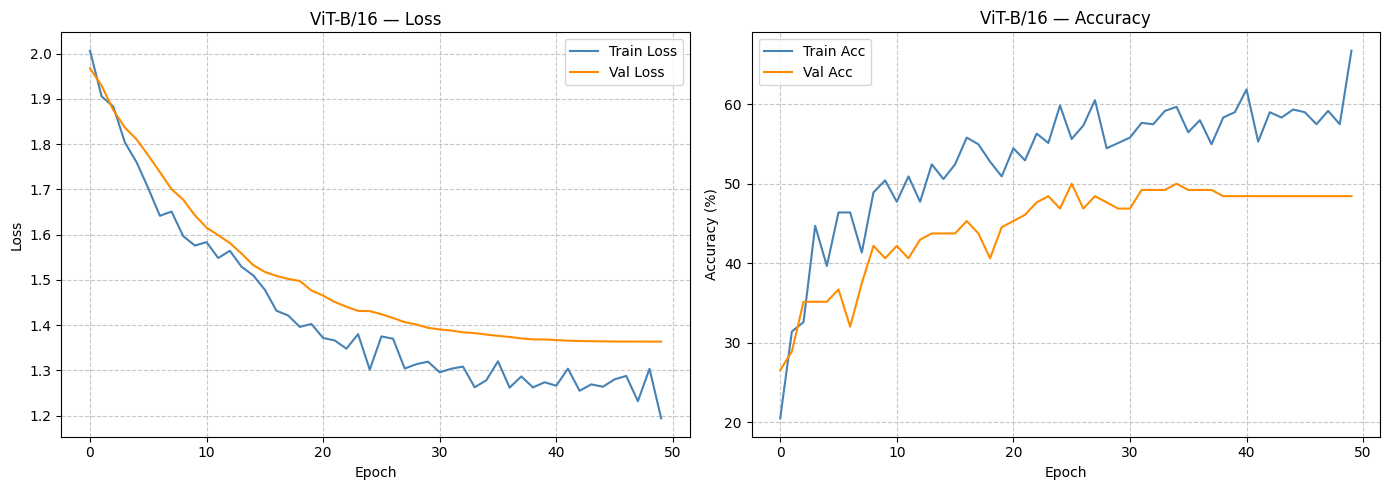

In [60]:
# Training curves for ViT-B/16
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(vit_train_losses, label='Train Loss', color='steelblue')
ax1.plot(vit_val_losses, label='Val Loss', color='darkorange')
ax1.set_title('ViT-B/16 — Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(linestyle='--', alpha=0.7)

ax2.plot(vit_train_accuracies, label='Train Acc', color='steelblue')
ax2.plot(vit_val_accuracies, label='Val Acc', color='darkorange')
ax2.set_title('ViT-B/16 — Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [61]:
# Load best weights and evaluate on validation set
vit_model.load_state_dict(torch.load('best_gunshot_vit.pth', weights_only=True))
vit_model.eval()

val_preds, val_labels = [], []
with torch.no_grad():
    for features, labels in val_loader:
        features = features.to(device)
        outputs = vit_model(features)
        _, predicted = torch.max(outputs, 1)
        val_preds.extend(predicted.cpu().numpy())
        val_labels.extend(labels.numpy())

target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print('ViT-B/16 — Validation Classification Report')
print(classification_report(val_labels, val_preds, target_names=target_names))


ViT-B/16 — Validation Classification Report
                  precision    recall  f1-score   support

           AK-12       0.77      0.71      0.74        14
           AK-47       0.36      0.82      0.50        11
IMI Desert Eagle       0.41      0.73      0.52        15
        M-Family       0.00      0.00      0.00        30
            M249       0.43      0.40      0.41        15
           MG-42       0.56      0.67      0.61        15
             MP5       0.35      0.40      0.38        15
     Zastava M92       0.71      0.77      0.74        13

        accuracy                           0.48       128
       macro avg       0.45      0.56      0.49       128
    weighted avg       0.39      0.48      0.42       128



In [62]:
# Evaluate on test set and store result as vit_test_accuracy
vit_model.eval()
test_correct = 0
test_total = 0
vit_test_preds, vit_test_labels = [], []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = vit_model(features)
        _, predicted = torch.max(outputs, 1)
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)
        vit_test_preds.extend(predicted.cpu().numpy())
        vit_test_labels.extend(labels.cpu().numpy())

vit_test_accuracy = 100 * test_correct / test_total
print(f'ViT-B/16 Test Accuracy: {vit_test_accuracy:.2f}%')
target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print(classification_report(vit_test_labels, vit_test_preds, target_names=target_names))


ViT-B/16 Test Accuracy: 43.75%
                  precision    recall  f1-score   support

           AK-12       0.73      0.53      0.62        15
           AK-47       0.30      0.64      0.41        11
IMI Desert Eagle       0.30      0.60      0.40        15
        M-Family       0.00      0.00      0.00        30
            M249       0.43      0.40      0.41        15
           MG-42       0.55      0.80      0.65        15
             MP5       0.36      0.27      0.31        15
     Zastava M92       0.59      0.83      0.69        12

        accuracy                           0.44       128
       macro avg       0.41      0.51      0.44       128
    weighted avg       0.36      0.44      0.38       128



In [63]:
# Updated comparison table with all five models
header = f"{'Model':<22} {'Train Acc':>10} {'Val Acc':>10} {'Test Acc':>10}"
print(header)
print('-' * len(header))
print(f"{'GunshotCNN':<22} {cnn_train_accuracies[-1]:>9.2f}% {cnn_val_accuracies[-1]:>9.2f}% {cnn_test_accuracy:>9.2f}%")
print(f"{'EfficientNet-B0':<22} {eff_train_accuracies[-1]:>9.2f}% {eff_val_accuracies[-1]:>9.2f}% {eff_test_accuracy:>9.2f}%")
print(f"{'MobileNetV2':<22} {mob_train_accuracies[-1]:>9.2f}% {mob_val_accuracies[-1]:>9.2f}% {mob_test_accuracy:>9.2f}%")
print(f"{'DeepGunshotCNN':<22} {deep_train_accuracies[-1]:>9.2f}% {deep_val_accuracies[-1]:>9.2f}% {deep_test_accuracy:>9.2f}%")
print(f"{'ViT-B/16':<22} {vit_train_accuracies[-1]:>9.2f}% {vit_val_accuracies[-1]:>9.2f}% {vit_test_accuracy:>9.2f}%")


Model                   Train Acc    Val Acc   Test Acc
-------------------------------------------------------
GunshotCNN                 81.34%     69.53%     71.88%
EfficientNet-B0            77.98%     64.84%     67.19%
MobileNetV2                72.44%     68.75%     63.28%
DeepGunshotCNN             80.17%     64.84%     73.44%
ViT-B/16                   66.72%     48.44%     43.75%


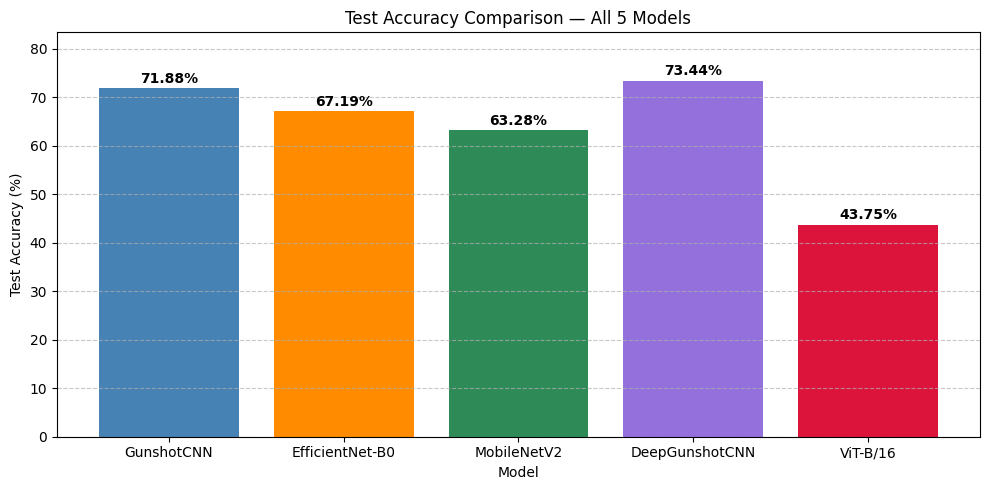

In [64]:
# Bar chart comparing test accuracy of all five models
model_names_all = ['GunshotCNN', 'EfficientNet-B0', 'MobileNetV2', 'DeepGunshotCNN', 'ViT-B/16']
test_accuracies_all = [cnn_test_accuracy, eff_test_accuracy, mob_test_accuracy, deep_test_accuracy, vit_test_accuracy]
colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'crimson']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_names_all, test_accuracies_all, color=colors)

for bar, acc in zip(bars, test_accuracies_all):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Model')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy Comparison — All 5 Models')
ax.set_ylim(0, max(test_accuracies_all) + 10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [65]:
# Load best weights for new models, wrap in AudioPipeline, save with joblib
deep_model.load_state_dict(torch.load('best_gunshot_deep_cnn.pth', weights_only=True))
vit_model.load_state_dict(torch.load('best_gunshot_vit.pth', weights_only=True))

deep_pipeline = AudioPipeline(deep_model, class_to_idx, idx_to_class)
vit_pipeline = AudioPipeline(vit_model, class_to_idx, idx_to_class)

joblib.dump(deep_pipeline, 'gunshot_deep_cnn_pipeline.joblib')
print('Saved gunshot_deep_cnn_pipeline.joblib')

joblib.dump(vit_pipeline, 'gunshot_vit_pipeline.joblib')
print('Saved gunshot_vit_pipeline.joblib')


Saved gunshot_deep_cnn_pipeline.joblib
Saved gunshot_vit_pipeline.joblib


In [66]:
# Load both new pipelines from disk and run a test prediction to confirm they work
loaded_deep = joblib.load('gunshot_deep_cnn_pipeline.joblib')
loaded_vit = joblib.load('gunshot_vit_pipeline.joblib')

sample_file = list(Path('../gunshot-audio-dataset').rglob('*.wav'))[0]
print(f'Test file: {sample_file.name}\n')

for name, pipeline in [('DeepGunshotCNN', loaded_deep), ('ViT-B/16', loaded_vit)]:
    pred_class, confidence = pipeline.predict(sample_file)
    print(f'{name:<22} Predicted: {pred_class:<20} Confidence: {confidence:.2f}%')


Test file: 3 (1).wav

DeepGunshotCNN         Predicted: AK-12                Confidence: 97.51%
ViT-B/16               Predicted: AK-12                Confidence: 34.15%


In [67]:
import pickle

preprocessing_config = {
    "target_sr": 48000,
    "target_sec": 2,
    "pre_emphasis_coeff": 0.97,
    "n_mfcc": 40,
    "n_fft": 1024,
    "hop_length": 512,
    "n_mels": 64,
    "noise_gate_threshold": 0.0
}
class_mapping = {
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class
}
with open("preprocessing_config.pkl", "wb") as f:
    pickle.dump(preprocessing_config, f)
with open("class_mapping.pkl", "wb") as f:
    pickle.dump(class_mapping, f)
print("[+] preprocessing_config.pkl saved")
print("[+] class_mapping.pkl saved")

[+] preprocessing_config.pkl saved
[+] class_mapping.pkl saved
